<a href="https://colab.research.google.com/github/hridibazaman03/220142_Decision-Tree/blob/main/220142_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
url = "https://raw.githubusercontent.com/hridibazaman03/220142_Decision-Tree/main/Titanic-Dataset.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(891, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


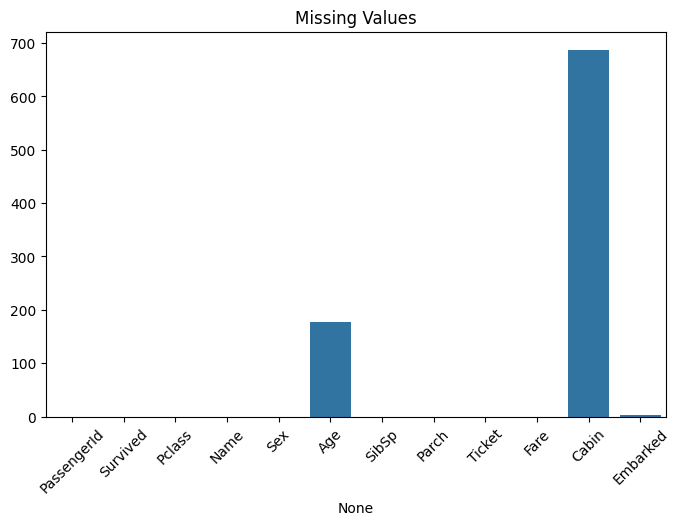

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
missing = df.isnull().sum()

plt.figure(figsize=(8,5))
sns.barplot(x=missing.index,y=missing.values)

plt.xticks(rotation=45)
plt.title("Missing Values")
plt.show()

print(missing)

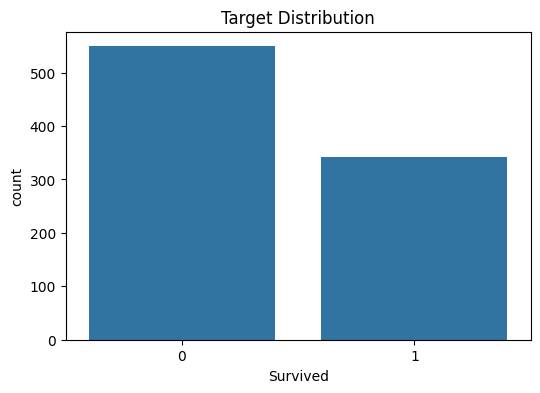

Survived
0    549
1    342
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x='Survived')

plt.title("Target Distribution")
plt.show()

print(df['Survived'].value_counts())

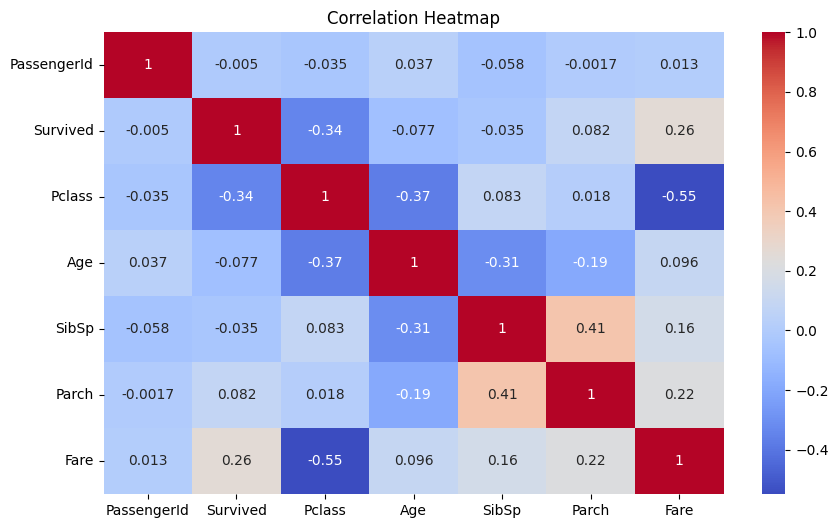

In [7]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
df.drop(
    ['PassengerId','Name','Ticket','Cabin'],
    axis=1,
    inplace=True
)

X = df.drop('Survived',axis=1)
y = df['Survived']

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [9]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [11]:
cart_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        random_state=42
    ))
])

param_grid = {
    'classifier__max_depth':[3,5,7,10,None],
    'classifier__min_samples_split':[2,5,10,20]
}

cart_grid = GridSearchCV(
    cart_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

cart_grid.fit(X_train,y_train)

best_cart = cart_grid.best_estimator_

print(cart_grid.best_params_)

{'classifier__max_depth': 5, 'classifier__min_samples_split': 5}


In [12]:
id3_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='entropy',
        random_state=42
    ))
])

id3_grid = GridSearchCV(
    id3_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

id3_grid.fit(X_train,y_train)

best_id3 = id3_grid.best_estimator_

print(id3_grid.best_params_)

{'classifier__max_depth': 5, 'classifier__min_samples_split': 10}


In [13]:
cart_pred = best_cart.predict(X_test)
cart_prob = best_cart.predict_proba(X_test)[:,1]

id3_pred = best_id3.predict(X_test)
id3_prob = best_id3.predict_proba(X_test)[:,1]

In [14]:
metrics = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1','AUC'],
    'CART':[
        accuracy_score(y_test,cart_pred),
        precision_score(y_test,cart_pred),
        recall_score(y_test,cart_pred),
        f1_score(y_test,cart_pred),
        roc_auc_score(y_test,cart_prob)
    ],
    'ID3':[
        accuracy_score(y_test,id3_pred),
        precision_score(y_test,id3_pred),
        recall_score(y_test,id3_pred),
        f1_score(y_test,id3_pred),
        roc_auc_score(y_test,id3_prob)
    ]
})

metrics

,Metric,CART,ID3
0,Accuracy,0.782123,0.770950
1,Precision,0.767857,0.769231
2,Recall,0.623188,0.579710
3,F1,0.688000,0.661157
4,AUC,0.791765,0.804809


In [15]:
X_processed = preprocessor.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

In [16]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cart_vis = DecisionTreeClassifier(
    criterion='gini',
    max_depth=cart_grid.best_params_['classifier__max_depth'],
    min_samples_split=cart_grid.best_params_['classifier__min_samples_split'],
    random_state=42
)


id3_vis = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=id3_grid.best_params_['classifier__max_depth'],
    min_samples_split=id3_grid.best_params_['classifier__min_samples_split'],
    random_state=42
)


cart_vis.fit(X_train_pca, y_train_pca)
id3_vis.fit(X_train_pca, y_train_pca)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=42)

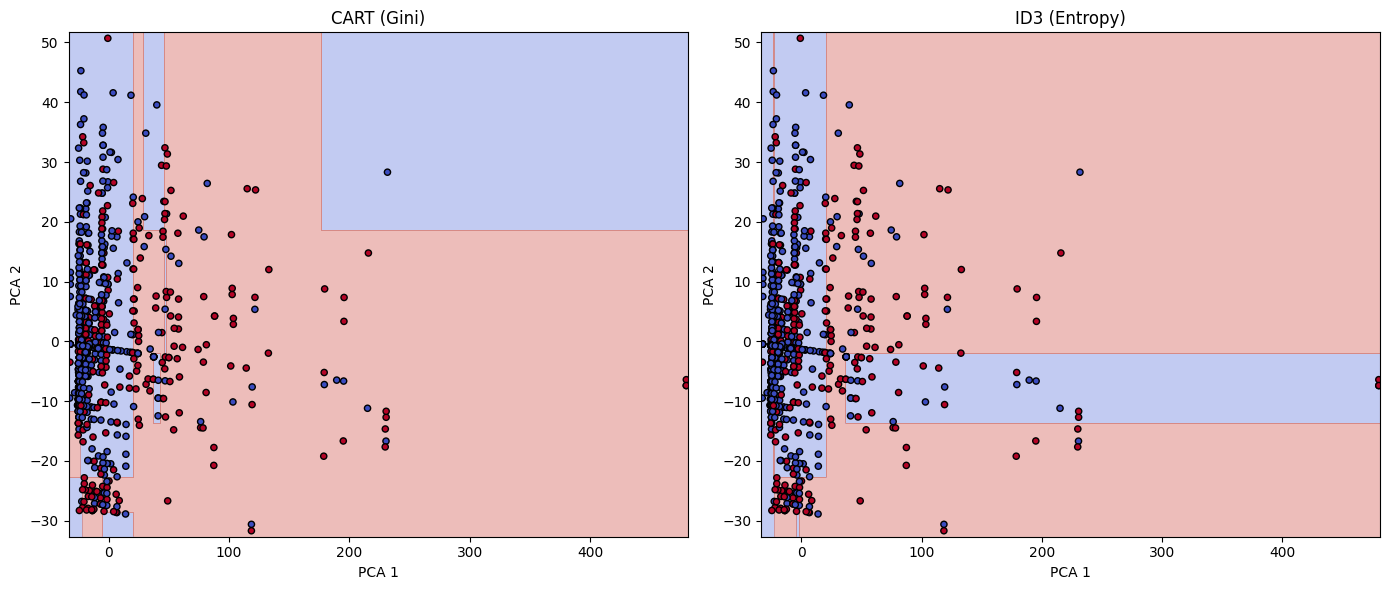

In [17]:
#Decision boundary

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = [cart_vis, id3_vis]
titles = ["CART (Gini)", "ID3 (Entropy)"]

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid = np.c_[xx.ravel(), yy.ravel()]

for ax, model, title in zip(axes, models, titles):

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="k",
        s=20
    )

    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

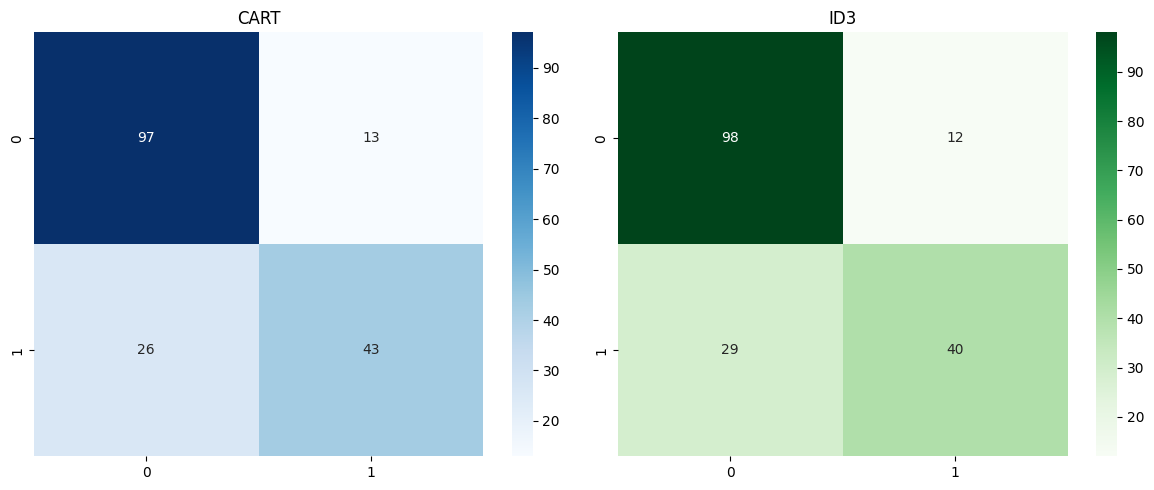

In [18]:
#Confusion matrix

fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test,cart_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("CART")

sns.heatmap(
    confusion_matrix(y_test,id3_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title("ID3")

plt.tight_layout()
plt.show()

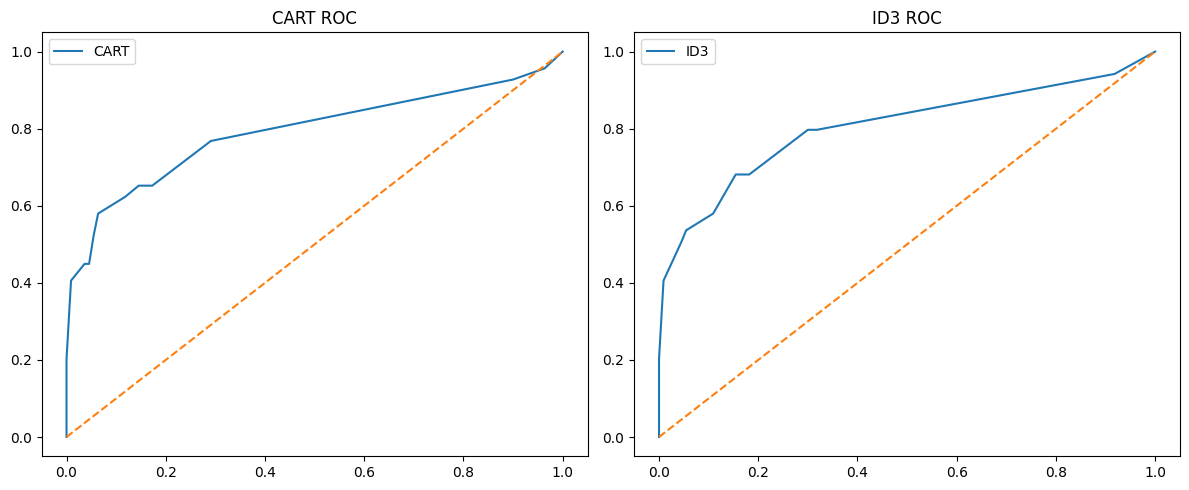

In [19]:
fpr_cart,tpr_cart,_ = roc_curve(y_test,cart_prob)
fpr_id3,tpr_id3,_ = roc_curve(y_test,id3_prob)

fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].plot(fpr_cart,tpr_cart,label='CART')
axes[0].plot([0,1],[0,1],'--')
axes[0].set_title('CART ROC')
axes[0].legend()

axes[1].plot(fpr_id3,tpr_id3,label='ID3')
axes[1].plot([0,1],[0,1],'--')
axes[1].set_title('ID3 ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

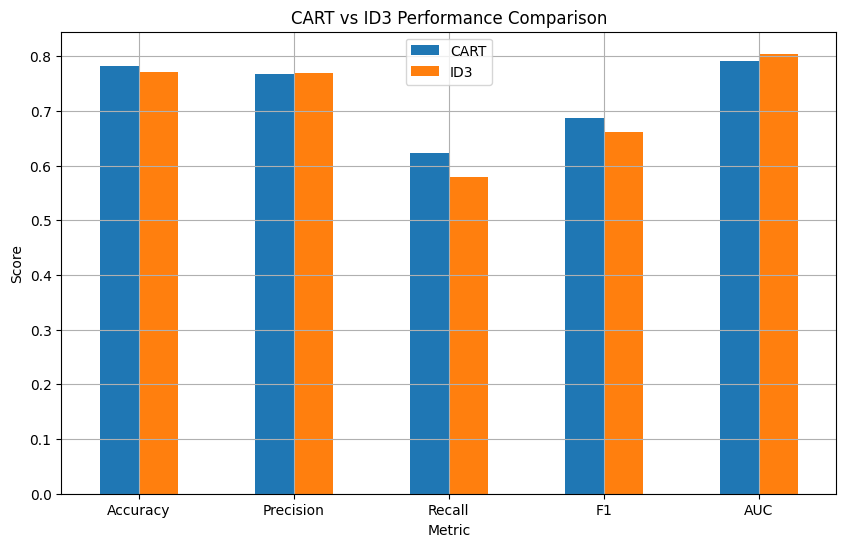

In [20]:
metrics_plot = metrics.set_index('Metric')

metrics_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("CART vs ID3 Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True)

plt.show()

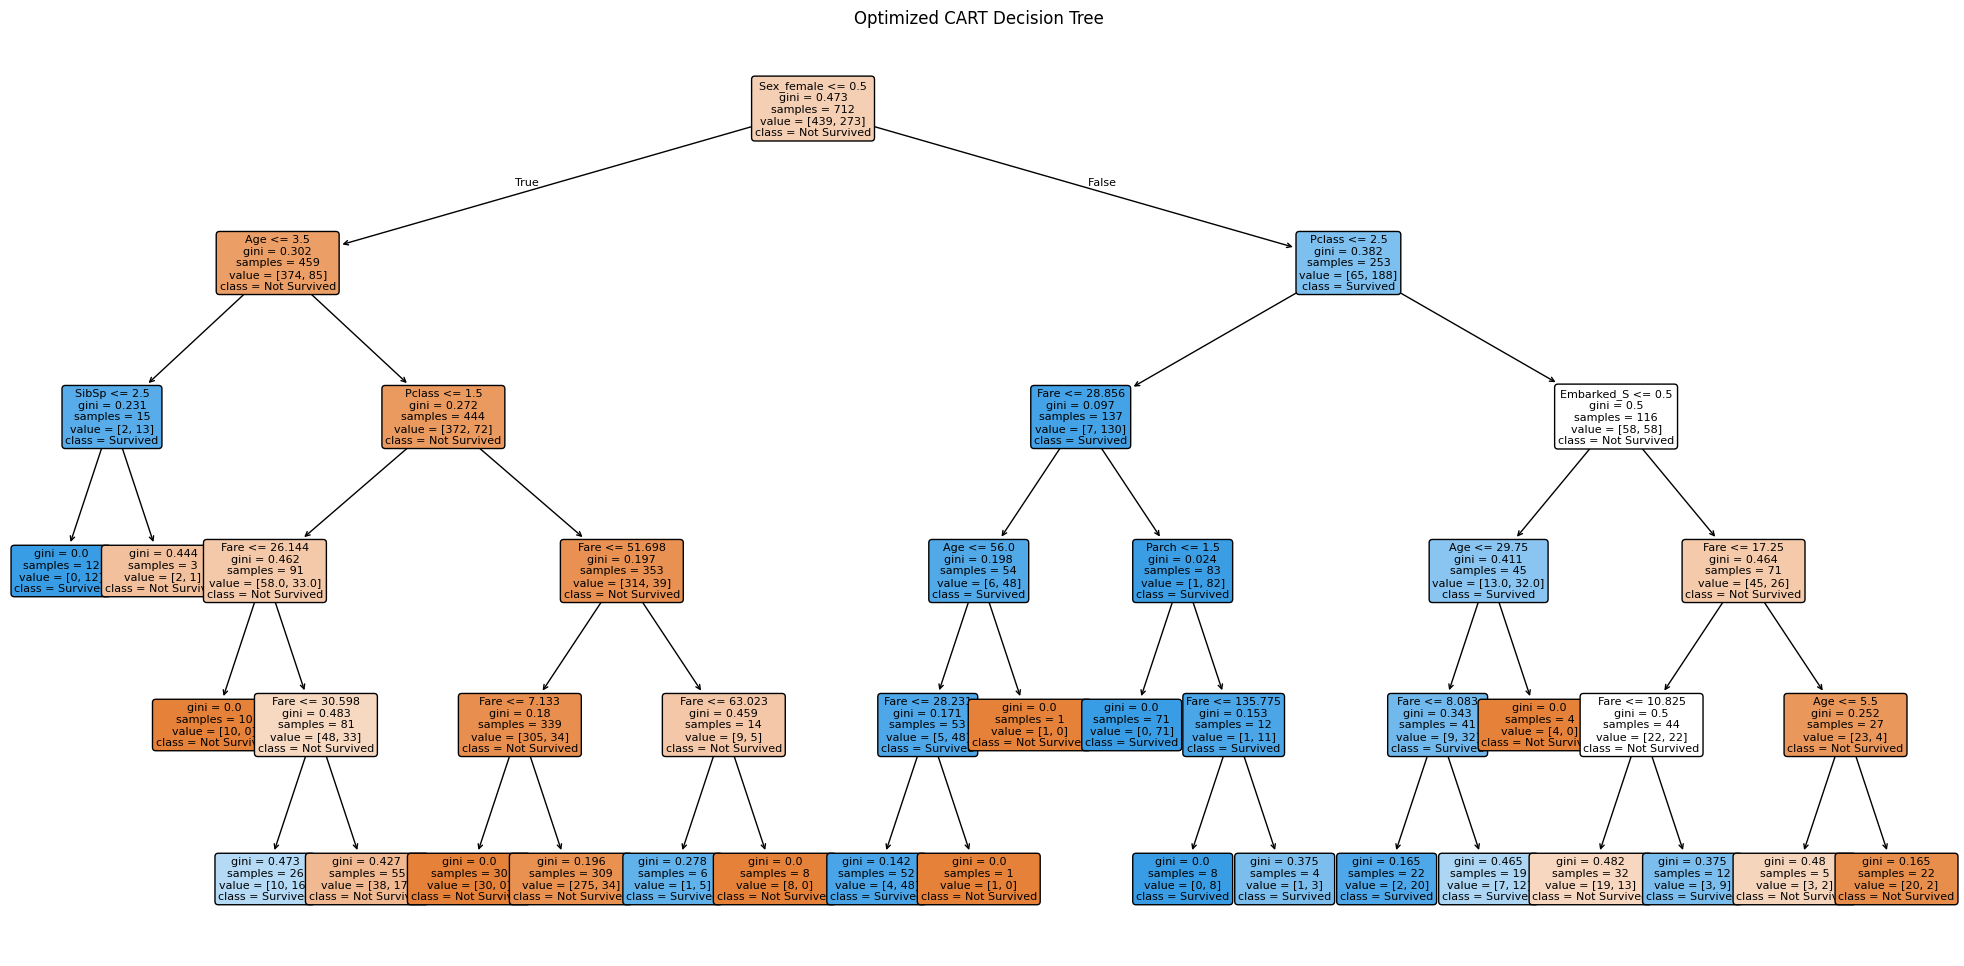

In [21]:
feature_names = (
    numerical_cols.tolist() +
    list(
        best_cart.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(categorical_cols)
    )
)

best_tree = best_cart.named_steps['classifier']

plt.figure(figsize=(25,12))

plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=['Not Survived','Survived'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Optimized CART Decision Tree")
plt.show()

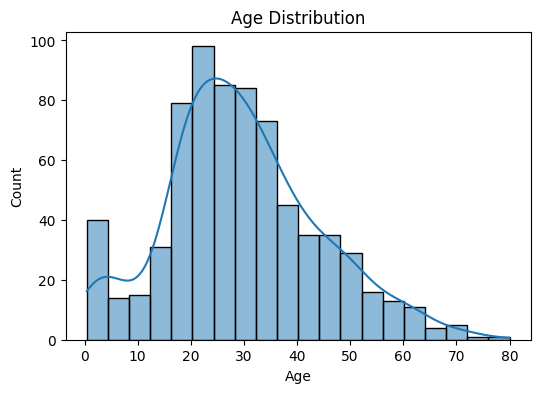

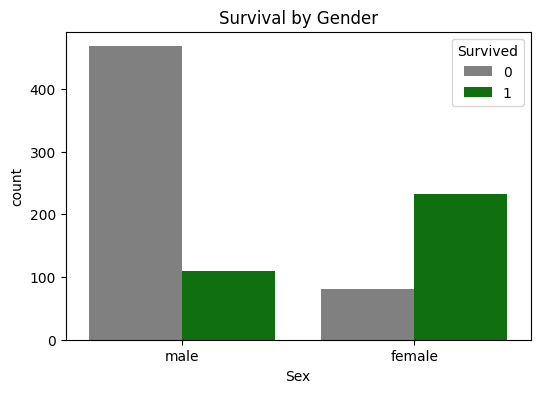

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()


plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='Sex',
    hue='Survived',
    palette=['grey', 'green']
)

plt.title("Survival by Gender")
plt.show()